## Load partition files, imports, and style

In [1]:
%matplotlib inline

In [2]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from pathlib import Path
import seaborn as sns
from sklearn.decomposition import PCA
from netgraph import Graph
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

OUT = Path('karate_figures')
OUT.mkdir(exist_ok=True)
print('Output directory:', OUT.resolve())

Output directory: /Users/yanyan/Documents/coding files/senior_research/karate_figures


In [8]:
# Load partition files
partition_names = ['louvain_karate', 'greedy_karate', 'greedy_bestn_karate', 'hybrid_optimized_karate', 'qpu_optimized_karate']
method_labels   = ['Louvain', 'Greedy', 'Greedy (best_n)', 'Hybrid', 'QPU']

partitions = {}
for name, label in zip(partition_names, method_labels):
    path = Path(f'partitions/partition_{name}.json')
    with open(path) as f:
        partitions[label] = np.array(json.load(f))
    print(f'Loaded {label}: {len(np.unique(partitions[label]))} communities')

# Load graph and adjacency matrix
G = nx.read_graphml('karate_club.graphml')
G.remove_nodes_from(list(nx.isolates(G)))
G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))
A = nx.adjacency_matrix(G_undirected, weight=None).toarray().astype(float)
N = G_undirected.number_of_nodes()
print(f'Graph: {N} nodes, {G_undirected.number_of_edges()} edges')


Loaded Louvain: 4 communities
Loaded Greedy: 3 communities
Loaded Greedy (best_n): 3 communities
Loaded Hybrid: 4 communities
Loaded QPU: 2 communities
Graph: 34 nodes, 78 edges


In [9]:
def compute_modularity(partition, A):
    degrees = A.sum(axis=1)
    m = A.sum() / 2.0
    Q = 0.0
    for i in range(len(partition)):
        for j in range(len(partition)):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    return Q / (2.0 * m)

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
    return (np.mean(conductances)+(singleton_count/77)+(double_count/(77*2))) if conductances else np.nan


def method_stats(partitions_dict, A):
    rows = []
    for label, p in partitions_dict.items():
        rows.append({
            'Method': label,
            'Modularity': compute_modularity(p, A),
            'Conductance': compute_conductance(p, A),
            'Communities': len(np.unique(p)),
        })
    return pd.DataFrame(rows)

stats = method_stats(partitions, A)
print(stats.to_string(index=False))

         Method  Modularity  Conductance  Communities
        Louvain    0.390450     0.352778            4
         Greedy    0.380671     0.280830            3
Greedy (best_n)    0.380671     0.280830            3
         Hybrid    0.419790     0.287500            4
            QPU    0.371795     0.128205            2


In [10]:
plt.rcParams.update({
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'axes.linewidth':     0.8,
    'xtick.major.width':  0.8,
    'ytick.major.width':  0.8,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.dpi':         300,
    'savefig.dpi':        300,
})


## Figures

### Modularity

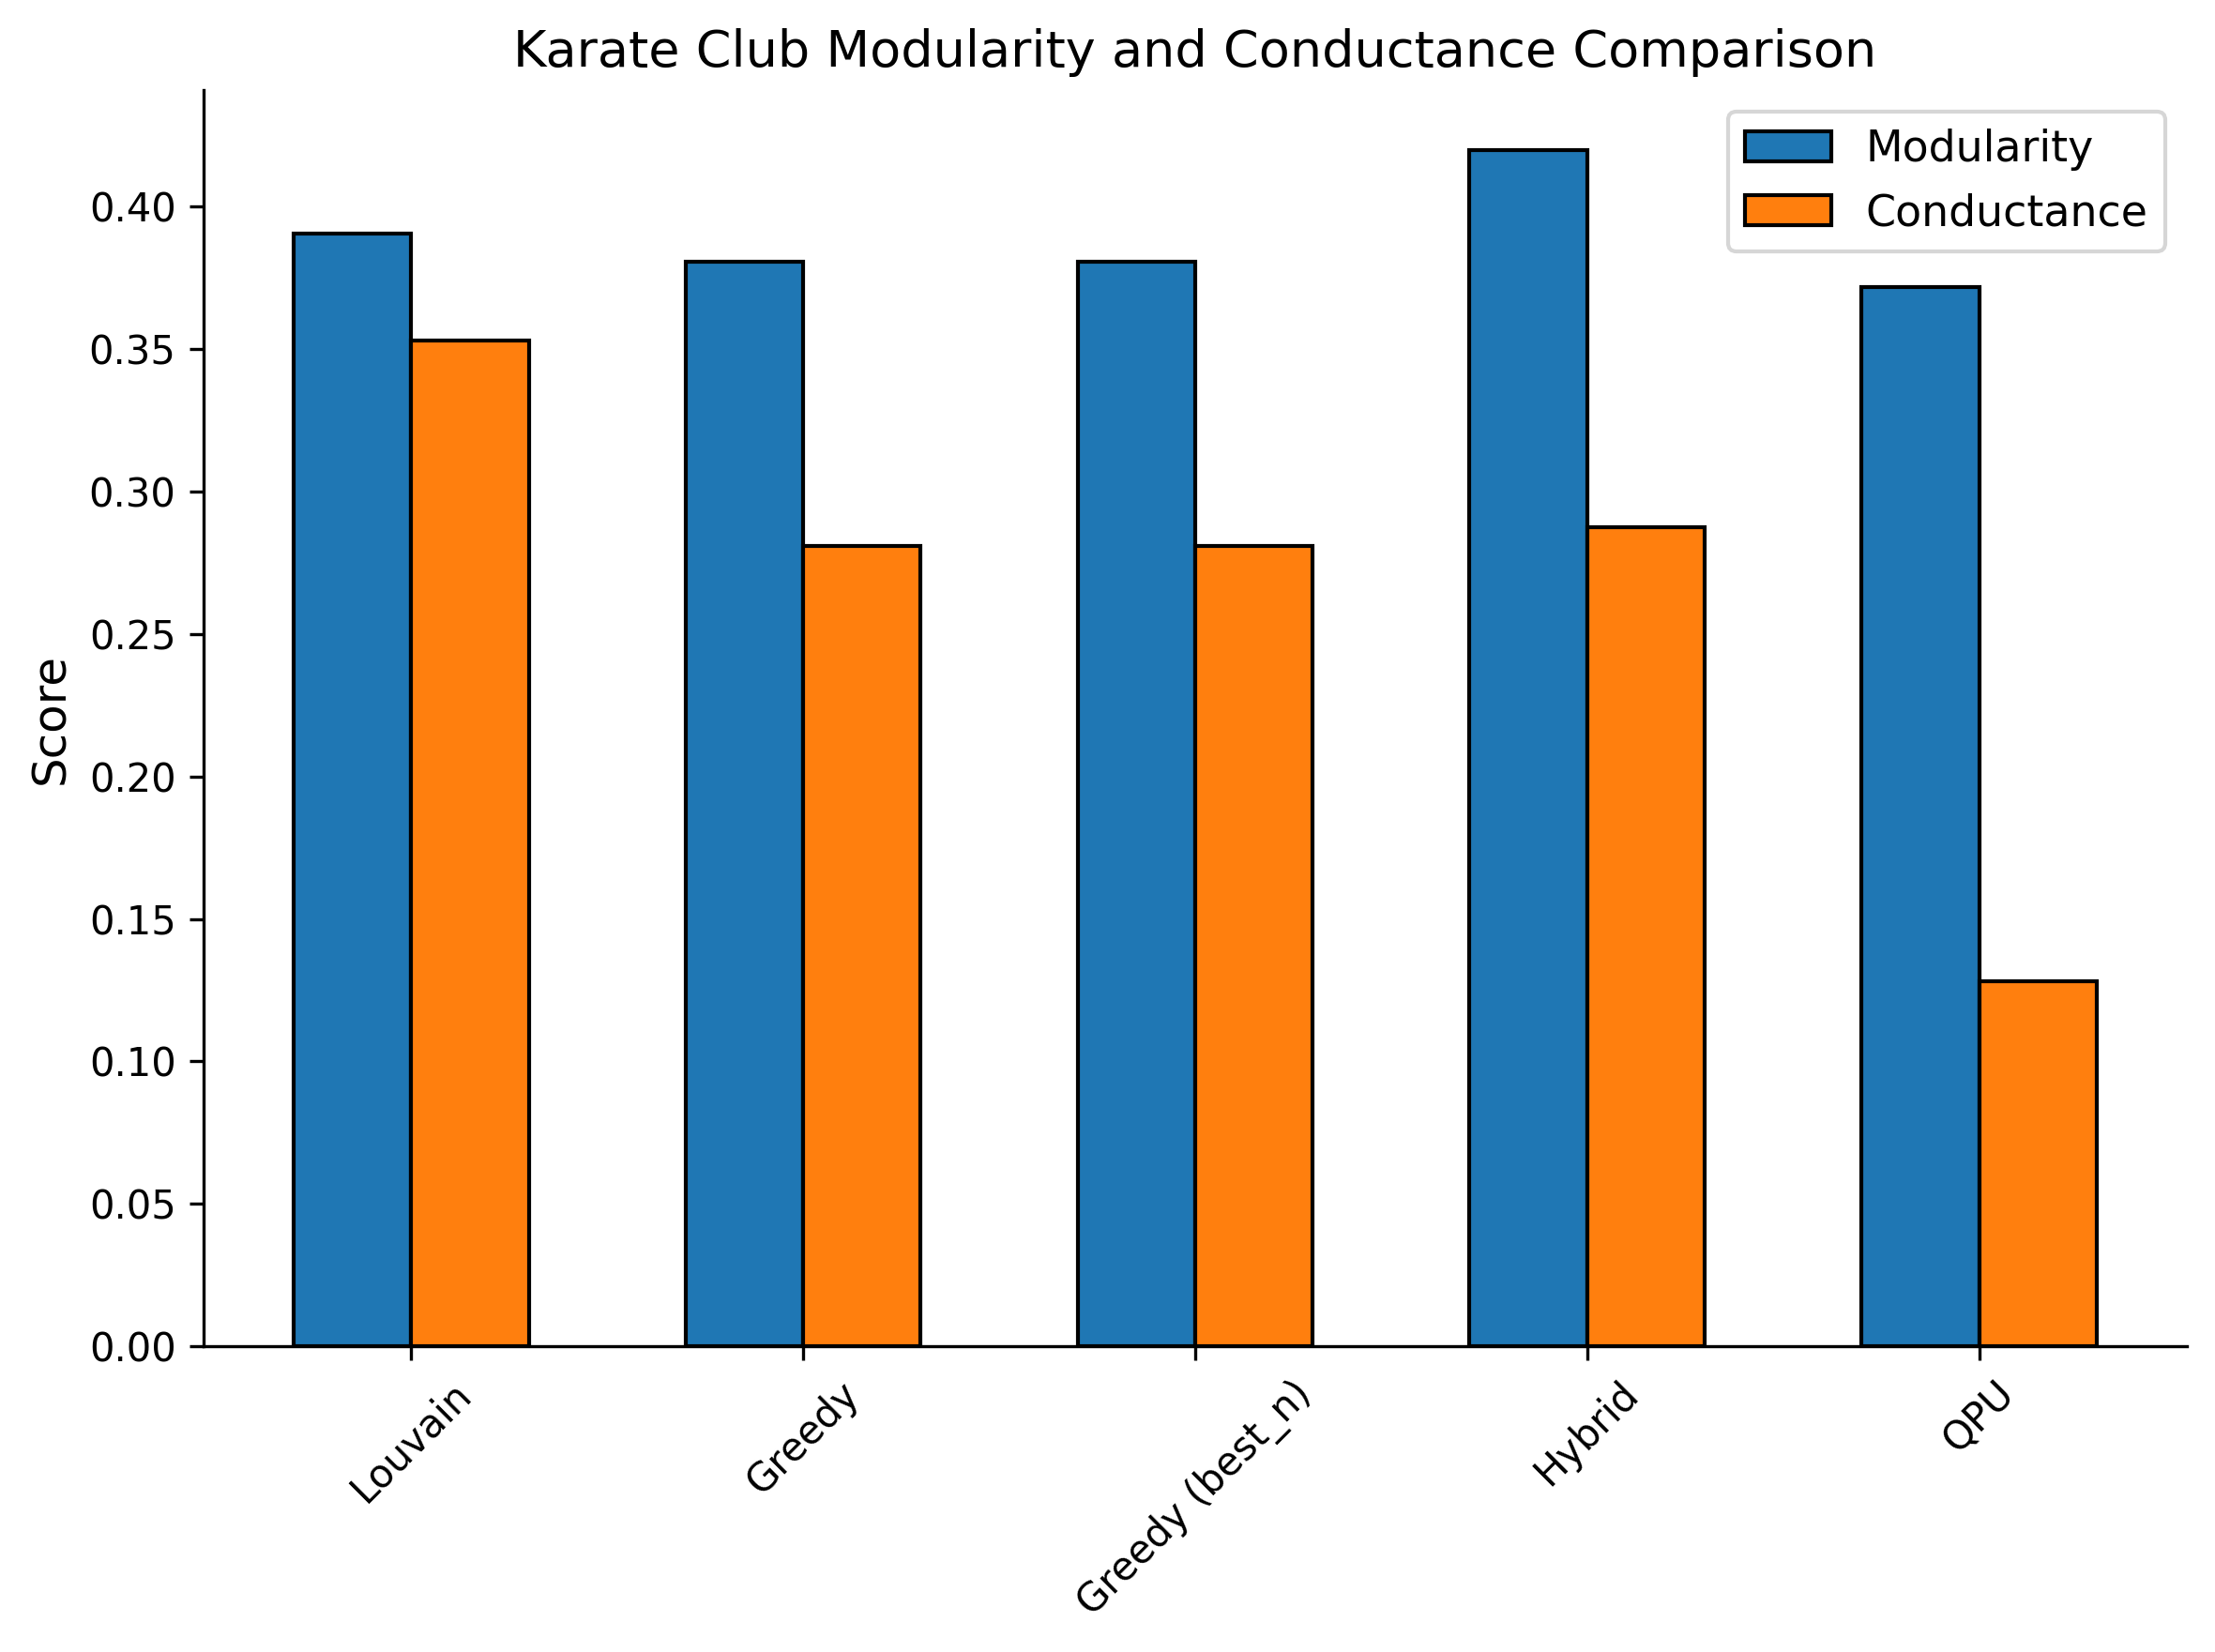

In [11]:
methods = stats['Method']
modularity = stats['Modularity']
conductance = stats['Conductance']

x = np.arange(len(methods))
width = 0.3  # width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
bar1 = ax.bar(x - width/2, modularity, width, label='Modularity', edgecolor='black', linewidth=1)
bar2 = ax.bar(x + width/2, conductance, width, label='Conductance', edgecolor='black', linewidth=1)

ax.set_ylabel('Score')
ax.set_title('Karate Club Modularity and Conductance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fig1_modularity_conductance_comparison.png', bbox_inches='tight')
#plt.show()